In [12]:
import sys
sys.path.append("../../src")
import numpy as np
from numpy import cos, sin, exp, pi, sqrt, abs
from mpmath import pcfd
import kblock_ising_model as kb
import kibble_zurek as kz



In [13]:

def sigmaz_general(indices,state):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = kz.D(-Nd,state)
   # print(C)
    return np.linalg.det(C)
##Projector Functions 
from itertools import combinations
from collections import Counter

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


#Typical Pn function
def P_zn(n,state):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigmaz_general(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


def P_nU(n,U,k):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigmaz_general_U(indices,U,k)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

In [14]:

def sigmaz_general_U(indices,T,k):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)

    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = kb.D(Nd,T,k)
    return np.linalg.det(C)

In [4]:
n=1

P_zn(n,state)


NameError: name 'state' is not defined

In [5]:
L = 100
taus = np.logspace(-2,2,50)
n_max = 10
data = np.zeros([n_max,len(taus)])
data_x = np.zeros([n_max,len(taus)])
labels = []
for i,n in enumerate(range(1,n_max+1)):
    labels.append(f"n= {n}")
    for j,tau in enumerate(taus):
        ti = tau
        ###
        state = kz.state(L,tau,ti)
        kvals = kb.k_vals(100)
        g0= kz.g(ti,tau)
        U0 = kb.U(kvals,-g0)
        ###
        kz_sol= P_zn(n,state)
        gs_sol= P_nU(n,U0,kvals)
    #    print(gs_sol)
        data[i,j] = np.abs(kz_sol-gs_sol)
        #X correlations
        kz_sol = kz.P_n(n,state)
        gs_sol = kb.P_n(n,U0,kvals)
        data_x[i,j]= np.abs(kz_sol-gs_sol)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18403/3750523481.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18403/552256436.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kb.D(Nd,T,k)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


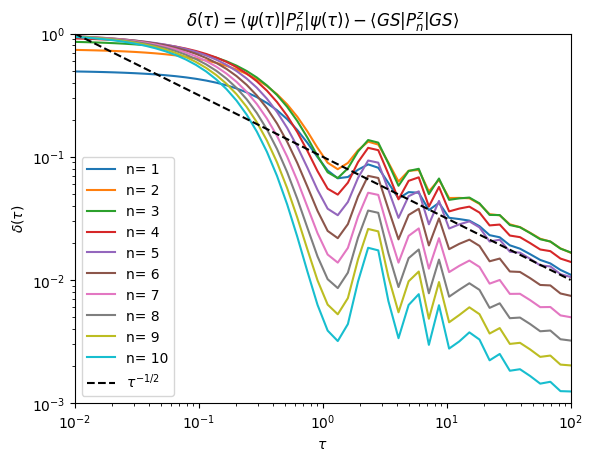

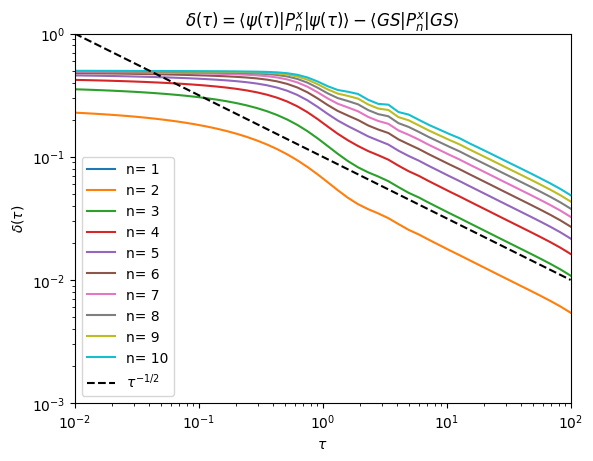

In [15]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, loglog, scatter, xlabel, ylabel, xlim, ylim,legend


plt.plot(taus,data.T,label=labels)
plt.plot(taus,taus**(-1/2)/taus[0]**(-1/2),color="black",ls="--",label=r"$\tau^{-1/2}$")
xlim(taus[0],taus[-1])
loglog()
plt.xscale("log")
legend()
plt.ylabel(r"$\delta(\tau)$")
xlabel(r"$\tau$")
plt.title(r"$\delta(\tau)= \langle \psi(\tau)| P^z_n | \psi(\tau)\rangle - \langle GS | P^z_n | GS \rangle$")
ylim(0.001,1)

plt.show()

import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, loglog, scatter, xlabel, ylabel, xlim, ylim,legend


plt.plot(taus,data_x.T,label=labels)
plt.plot(taus,taus**(-1/2)/taus[0]**(-1/2),color="black",ls="--",label=r"$\tau^{-1/2}$")
xlim(taus[0],taus[-1])
plt.xscale("log")
loglog()
legend()
plt.ylabel(r"$\delta(\tau)$")
xlabel(r"$\tau$")
plt.title(r"$\delta(\tau)= \langle \psi(\tau)| P^x_n | \psi(\tau)\rangle - \langle GS | P^x_n | GS \rangle$")
ylim(0.001,1)

plt.show()

In [53]:
from tqdm import tqdm
import numpy as np

L = 100
taus = np.logspace(-2, 2, 50)
n_max = 7
data_z = np.zeros([n_max, len(taus)])
data_x = np.zeros([n_max, len(taus)])
labels = [f"n= {n}" for n in range(1, n_max + 1)]

t_array = [np.linspace(-tau, tau, 100) for tau in taus]

for j, tau in enumerate(tqdm(taus)):
    t = t_array[j]
    for k, ti in enumerate(t):
        state = kz.state(L, tau, ti)
        kvals = kb.k_vals(L)
        g0 = kz.g(ti, tau)
        U0 = kb.U(kvals, -g0)

        for i, n in enumerate(range(1, n_max + 1)):
            # Z correlations
            kz_sol_z = P_zn(n, state)
            gs_sol_z = P_nU(n, U0, kvals)
            diff = np.abs(kz_sol_z - gs_sol_z)
            data_z[i, j] += diff / len(t)

            # X correlations
            kz_sol_x = kz.P_n(n, state)
            gs_sol_x = kb.P_n(n, U0, kvals)
            diff = np.abs(kz_sol_x - gs_sol_x)
            data_x[i, j] += diff / len(t)


  0%|          | 0/50 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_77589/3750523481.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_77589/552256436.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kb.D(Nd,T,k)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 50/50 [08:41<00:00, 10.42s/it]


'$\\Delta(\\tau) = \\int (\\delta(t))$'

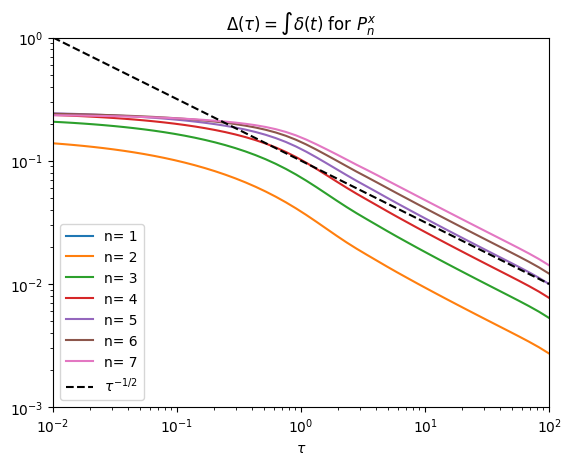

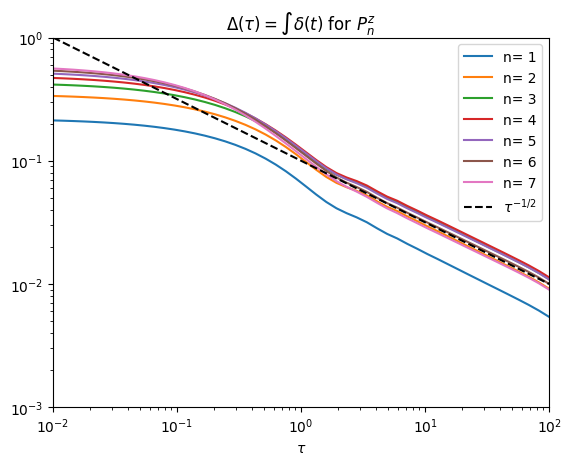

In [76]:
plot(taus,data_x.T,label= labels)
plot(taus,taus**(-1/2)/taus[0]**(-1/2),color="black",ls="--",label=r"$\tau^{-1/2}$")
legend()
loglog()
xlim(taus[0],taus[-1])
ylim(0.001,1)
plt.title(r"$\Delta(\tau) = \int \delta(t)$ for $P^x_n$")
xlabel(r"$\tau$")
#####
plt.show()
#####

plot(taus,data_z.T,label= labels)
loglog()
xlim(taus[0],taus[-1])
plot(taus,taus**(-1/2)/taus[0]**(-1/2),color="black",ls="--",label=r"$\tau^{-1/2}$")
plt.title(r"$\Delta(\tau) = \int \delta(t)$ for $P^z_n$")

ylim(0.001,1)

xlabel(r"$\tau$")
legend()
plt.show()


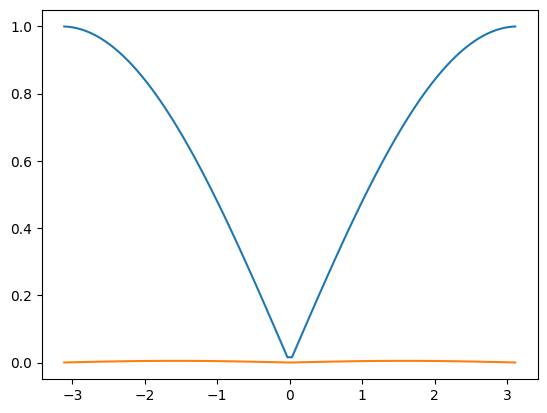

In [29]:


plt.plot(kvals,kb.U(kvals,0)[0])
plt.plot(kvals,kb.U(kvals,-100)[0])

#plt.plot(kvals,np.cos(kvals/2))

In [190]:
import numpy as np
from scipy.integrate import solve_ivp

# Momentum values (replace with your actual kz.k_vals)
L = 100
K_vals = np.linspace(0.1,np.pi-.1,L//2)  # your function
N_k = len(K_vals)

# Time discretization
tau = .1
t_span = (0, 2* tau)
t_eval = np.linspace(*t_span, 1000)
N_t = len(t_eval)

# Temporary storage for all k modes across time
psi0_all = np.zeros((N_k, N_t), dtype=complex)
psi1_all = np.zeros((N_k, N_t), dtype=complex)

for k_idx, k in enumerate(K_vals):



    # Time-dependent Hamiltonian for mode k
    def H_k(t):
        return 2*np.array([
            [(t/tau - np.cos(k)), 1j*np.sin(k)],
            [-1j*np.sin(k), -(t/tau - np.cos(k))]
        ], dtype=complex)

    # ODE: dψ/dt = -i H_k(t) ψ
    def rhs(t, psi):
        return -1j * H_k(t) @ psi

    # Initial condition: ground state at t = 0
    eigvals, eigvecs = np.linalg.eigh(H_k(t_span[0]))
    psi_init = eigvecs[:, 0]
    # Solve time evolution
    sol = solve_ivp(rhs, t_span, psi_init, t_eval=t_eval, rtol=1e-9, atol=1e-9)

    # Store results
    psi0_all[k_idx, :] = sol.y[0]
    psi1_all[k_idx, :] = sol.y[1]

# Construct final state list
state = []
for t_idx in range(N_t):
    psi0_t = psi0_all[:, t_idx]
    psi1_t = psi1_all[:, t_idx]
    state.append([psi1_t, psi0_t, K_vals])


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


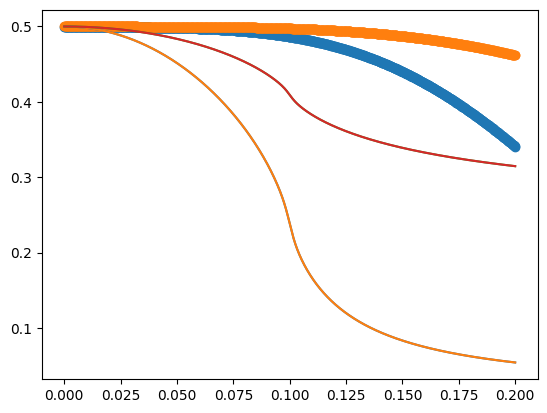

In [192]:
k0 = kb.k_vals(100)
dat=[]
for t in t_eval:
    U = kb.U(k0,t/tau)
    dat+=[kb.P_n(6,U,k0)]

plot(t_eval,dat)
plt.scatter(t_eval,[kz.P_n(6,s) for s in  state])
plot(t_eval,dat)

k0 = kb.k_vals(100)
dat=[]
for t in t_eval:
    U = kb.U(k0,t/tau)
    dat+=[kb.P_n(2,U,k0)]

plot(t_eval,dat)
plt.scatter(t_eval,[kz.P_n(2,s) for s in  state])
plot(t_eval,dat)

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def evolve_TFIM_state(L=100, tau=0.1, t_final_factor=2, N_t=1000):
    """
    Solves the time-dependent BdG equations for the TFIM 
    with complex-valued Hamiltonian structure.
    
    Returns:
        state: list of [psi1_t, psi0_t, K_vals] at each time t
    """
    # Momentum values (avoid exact 0 and pi)
    K_vals = np.linspace(0.1, np.pi - 0.1, L // 2)
    N_k = len(K_vals)

    # Time grid
    t_span = (0, t_final_factor * tau)
    t_eval = np.linspace(*t_span, N_t)

    # Allocate solution arrays
    psi0_all = np.zeros((N_k, N_t), dtype=complex)
    psi1_all = np.zeros((N_k, N_t), dtype=complex)

    for k_idx, k in enumerate(K_vals):

        def H_k(t):
            gt = t / tau
            return 2 * np.array([
                [gt - np.cos(k), 1j * np.sin(k)],
                [-1j * np.sin(k), -(gt - np.cos(k))]
            ], dtype=complex)

        def rhs(t, psi):
            return -1j * H_k(t) @ psi

        # Initial state: ground state of H_k at t = 0
        eigvals, eigvecs = np.linalg.eigh(H_k(t_span[0]))
        psi_init = eigvecs[:, 0]

        sol = solve_ivp(rhs, t_span, psi_init, t_eval=t_eval, rtol=1e-9, atol=1e-9)
        assert sol.success, f"ODE failed for k={k}"

        psi0_all[k_idx, :] = sol.y[0]
        psi1_all[k_idx, :] = sol.y[1]

    # Reorganize into list of [psi1_t, psi0_t, K_vals]
    state = []
    for t_idx in range(N_t):
        psi0_t = psi0_all[:, t_idx]
        psi1_t = psi1_all[:, t_idx]
        state.append([psi1_t, psi0_t, K_vals])

    return [state,t_eval]
#state[0][0] is equilvanet ot kz.state

#state[1] is time evolution

In [ ]:
from tqdm import tqdm
taus = np.logspace(-2,2,25)
dat =[]
for tau in tqdm(taus):
    states =evolve_TFIM_state(100, tau, 4, 100)
    dat.append(states)

100%|██████████| 25/25 [01:23<00:00,  3.35s/it]


In [236]:
def groundstate(n,t,tau):
    g = t/tau
    k0 = kb.k_vals(100)
    U = kb.U(k0,g)
    return kb.P_n(n,U,k0)
def states_unpacker(dat,taus,n):
    delta=[]
    for i,tau in enumerate(taus):
        states = dat[i]
        times = states[1]
        P = []
        P0=[]
        for ti, t in enumerate(times):
            state = states[0][ti]
            P.append(kz.P_n(n,state))
            P0.append(groundstate(n,t,tau))
        P0 = np.array(P0)
        P = np.array(P)
        plot(times,P0)
        scatter(times,P,s=5)
        #plt.show()
        diff = np.mean(np.abs(P-P0))
        delta.append(diff)
    return delta
        

 20%|██        | 1/5 [00:00<00:01,  2.21it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 5/5 [01:10<00:00, 14.09s/it]


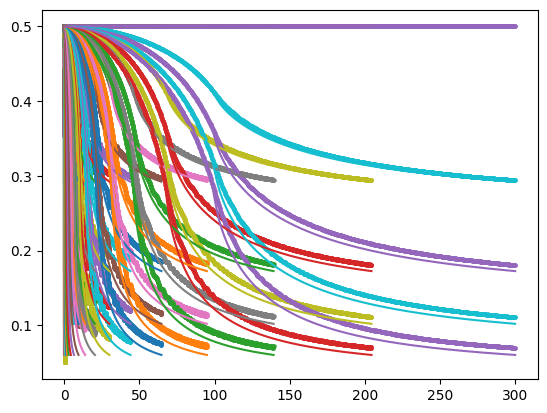

In [238]:
x= [states_unpacker(dat,taus,n) for n in tqdm(range(1,6))]

0.12547856628606383
0.20132917374799986
0.2507647920676612
0.28407479419973536


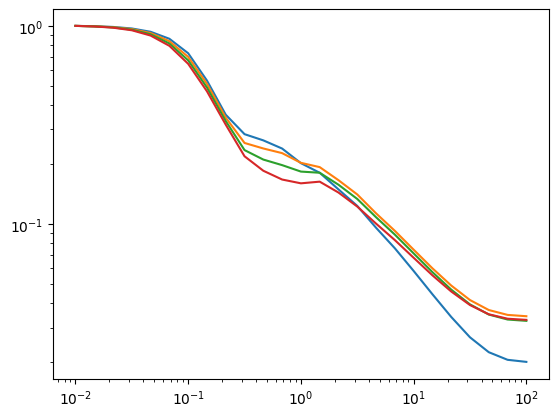

In [260]:
for xi in x[1:]:
    print(xi[0])
    plt.plot(taus,np.array(xi)/xi[0])
plt.yscale("log")
plt.xscale("log")

In [261]:
x=[0.12547856628606383,
0.20132917374799986,
0.2507647920676612,
0.28407479419973536]

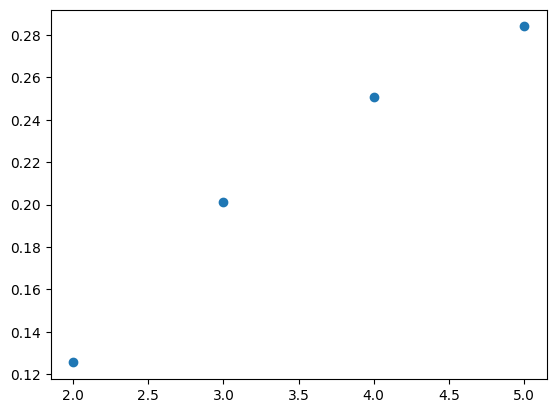

In [263]:
plt.scatter([2,3,4,5],x)

30it [00:41,  1.39s/it]


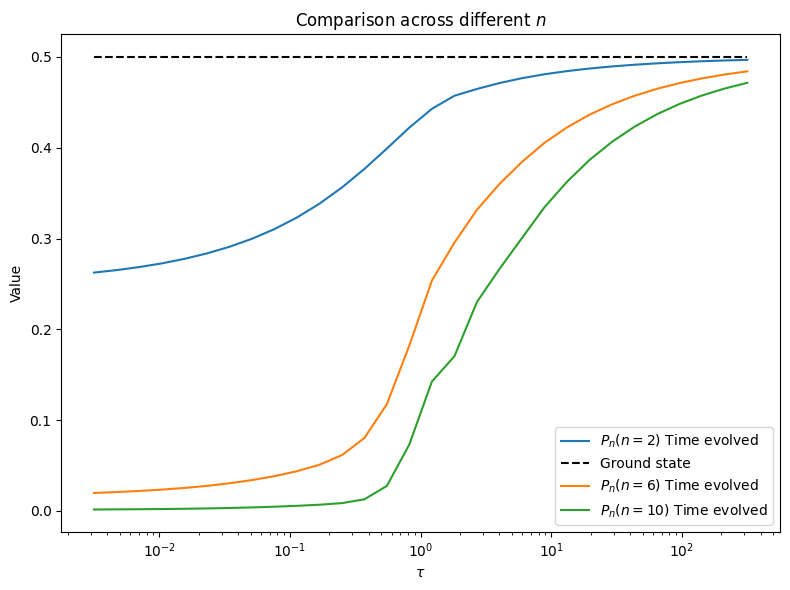

In [290]:
import numpy as np
import matplotlib.pyplot as plt

L = 1000
taus = np.logspace(-2.5, 2.5, 30)
n_values = [2,6,10]
N_n = len(n_values)
N_tau = len(taus)

# Preallocate arrays
KZ_array = np.zeros((N_n, N_tau))
GS_array = np.zeros((N_n, N_tau))
Delta_array = np.zeros((N_n, N_tau))

for j, tau in tqdm(enumerate(taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
    U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(n_values):
        P_kz = kz.P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        KZ_array[i, j] = P_kz
        GS_array[i, j] = P0
        Delta_array[i, j] = diff

# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


0it [00:00, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Z_projectors/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
30it [00:11,  2.70it/s]


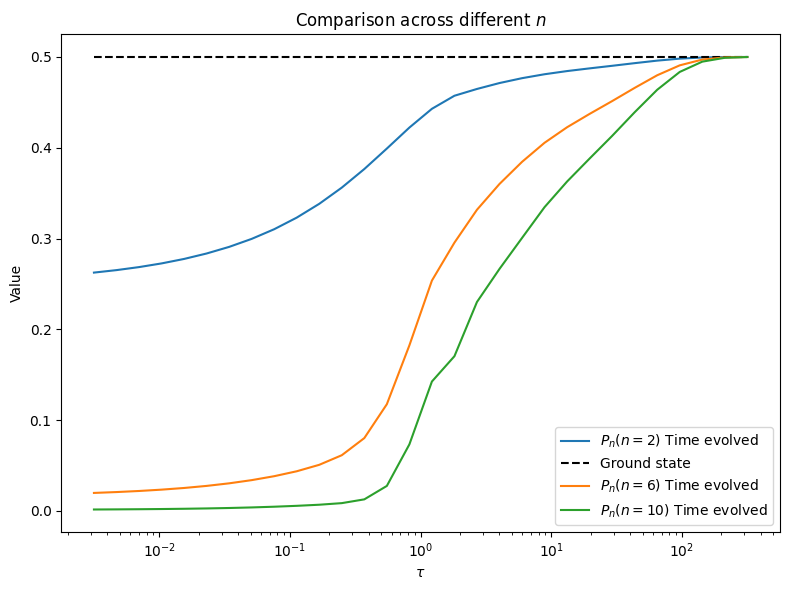

In [291]:
import numpy as np
import matplotlib.pyplot as plt
A = np.copy(KZ_array)

L = 50
taus = np.logspace(-2.5, 2.5, 30)
n_values = [2,6,10]
N_n = len(n_values)
N_tau = len(taus)

# Preallocate arrays
KZ_array = np.zeros((N_n, N_tau))
GS_array = np.zeros((N_n, N_tau))
Delta_array = np.zeros((N_n, N_tau))

for j, tau in tqdm(enumerate(taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
    U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(n_values):
        P_kz = kz.P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        KZ_array[i, j] = P_kz
        GS_array[i, j] = P0
        Delta_array[i, j] = diff

# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()



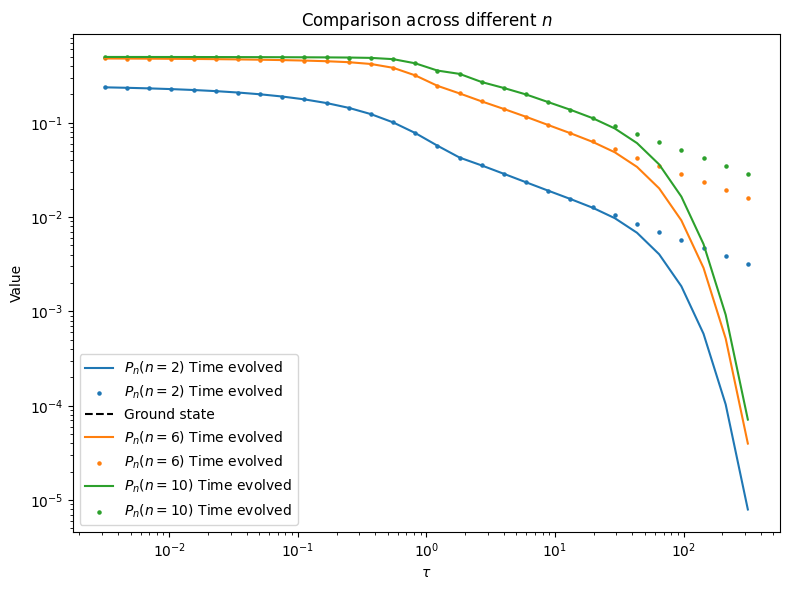

In [296]:
# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, 0.5-KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    plt.scatter(taus, 0.5-A[i], label=fr"$P_n(n={n})$ Time evolved",s=5)

    if i == 0:
        plt.plot(taus, 0.5-GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")
#plt.plot(taus,taus**(1/2))
plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()
